In [3]:
import numpy as np
import pandas as pd

In [4]:
data=pd.read_csv('MicrosoftStock.csv')

In [5]:
data.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [6]:
data['date']=pd.to_datetime(data['date'])

In [7]:
data.set_index('date',inplace=True)

In [8]:
data.drop(columns=['index'],inplace=True)

In [9]:
data.head()

,open,high,low,close,volume,Name
date,,,,,,
2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [10]:
from statsmodels.tsa.stattools import adfuller

In [11]:
adf_test=adfuller(data['close'])

In [11]:
print(f"adf stats:{round(adf_test[0],3)}")
print(f"p-value stats:{round(adf_test[1],3)}")

adf stats:0.416
p-value stats:0.982


In [1]:
# ADF    p-value	     Decision	         Conclusion
#       p < 0.05	Reject H₀	        ✅ Series is stationary
#      p  ≥ 0.05	Fail to reject H₀	❌ Series is non-stationary

In [12]:
for key,value in adf_test[4].items():
    print(f"{key}:{round(value,3)}")

1%:-3.436
5%:-2.864
10%:-2.568


In [12]:
#  adf_statistics<5% if statisfy then can say reject null hypothesis so data have stationarity.

#   0.416>-2.864  here failed to reject null hypothesis that data is stationarity means data is non stationary.

# So when someone says "stationary at the 5% level", they mean:

# The test provides statistically significant evidence of stationarity using α = 0.05.

In [18]:
from statsmodels.tsa.stattools import kpss

In [22]:
# H₀ (null): The series is stationary.

# H₁ (alternative): The series is non-stationary

# KPSS p-value	Decision	    Conclusion
# p < 0.05	Reject H₀	        Non-stationary
# p ≥ 0.05	Fail to reject H₀   Stationary


# Fist plot the graph data['close'].plot()
#then choose which to use
# No obvious trend
#       ↓
#     use 'c'

# Clear trend
#       ↓
#     use 'ct'

<Axes: xlabel='date'>

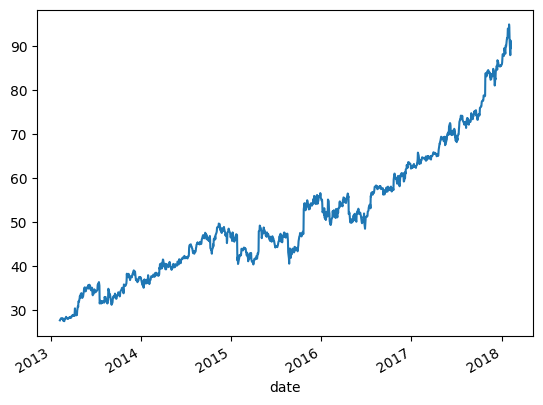

In [20]:
data['close'].plot() #clear trend of increasing/decreasing then use ct-constant+trend

In [21]:
kpss_test=kpss(data['close'],regression='ct')

C:\Users\Mcc\AppData\Local\Temp\ipykernel_31004\3465776723.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(data['close'],regression='ct')


In [ ]:
# ADF: p-value < 0.05
# KPSS: p-value > 0.05

# ➡️ Conclusion: Data is stationary. ✅

In [23]:
print(f"kpss stats:{round(kpss_test[0],3)}")
print(f"p-value stats:{round(kpss_test[1],3)}")
for key,value in kpss_test[3].items():
    print(f"{key}:{round(value,3)}")

kpss stats:0.877
p-value stats:0.01
10%:0.119
5%:0.146
2.5%:0.176
1%:0.216


In [24]:
from statsmodels.tsa.stattools import kpss

stat, p_value, lags, critical_values = kpss(data['close'], regression='ct')

print("KPSS Statistic:", stat)
print("p-value:", p_value)
print("Lags used:", lags)
print("Critical values:", critical_values)

KPSS Statistic: 0.876712863030781
p-value: 0.01
Lags used: 20
Critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


C:\Users\Mcc\AppData\Local\Temp\ipykernel_31004\2326159976.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, critical_values = kpss(data['close'], regression='ct')


In [25]:
#strict stationarity

In [29]:
from scipy import stats

In [30]:
from scipy.stats import ks_2samp

first_half = data['close'].iloc[:len(data)//2]
second_half = data['close'].iloc[len(data)//2:]

stat, p = ks_2samp(first_half, second_half)

In [32]:
# Hypotheses

# For ks_2samp():

# H₀: Both samples come from the same distribution.
# H₁: The two samples come from different distributions.

# p-value   interpretation
# p-value	Decision at 5%    	    Meaning
# p < 0.05	Reject H₀	            Distributions are significantly different
# p ≥ 0.05	Fail to reject H₀       No significant evidence that distributions differ

In [33]:
# KS test if p_value>0.05 no difference in distributuin

statistic, p_value = stats.ks_2samp(first_half, second_half)

print("KS Statistic:", statistic)
print("p-value:", p_value)
if p_value<0.05:
    print("Distributions are significantly different")
else:
    print("No significant evidence that distributions differ")

KS Statistic: 0.9095238095238095
p-value: 1.455326172763554e-279
Distributions are significantly different


making data stationary

In [34]:
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
    for key,value in adf_test[4].items():
     print(f"{key}:{round(value,3)}")
    

In [35]:
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    print("Lags used:", kpss_test[2])
    print("Critical values:", kpss_test[3].items())
    

In [36]:
price=data['close']

In [37]:
adf_test(price)

adf stats:0.416
p-value stats:0.982
1%:-3.436
5%:-2.864
10%:-2.568


In [38]:
kpss_test(price)

KPSS Statistic: 0.876712863030781
p-value: 0.01
Lags used: 20
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])


C:\Users\Mcc\AppData\Local\Temp\ipykernel_31004\1164356623.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')


In [43]:
diff_price=price.diff().dropna() #first order differing
print("1st difference:", round(adfuller(diff_price)[1],3))

1st difference: 0.0


In [44]:
from scipy import stats

In [45]:
log_price=np.log(price)

In [46]:
log_price

date
2013-02-08    3.316003
2013-02-11    3.327192
2013-02-12    3.327910
2013-02-13    3.333275
2013-02-14    3.333632
                ...   
2018-02-01    4.546057
2018-02-02    4.519394
2018-02-05    4.477337
2018-02-06    4.514479
2018-02-07    4.495467
Name: close, Length: 1259, dtype: float64

In [47]:
sqrt_price=np.sqrt(price)

In [48]:
sqrt_price

date
2013-02-08    5.248809
2013-02-11    5.278257
2013-02-12    5.280152
2013-02-13    5.294337
2013-02-14    5.295281
                ...   
2018-02-01    9.708759
2018-02-02    9.580188
2018-02-05    9.380832
2018-02-06    9.556673
2018-02-07    9.466256
Name: close, Length: 1259, dtype: float64

In [49]:
price_boxcox,lams=stats.boxcox(price[price>0])

In [50]:
price_boxcox

array([2.31106333, 2.31622991, 2.31656081, ..., 2.78157377, 2.79462403,
       2.78795799])

In [51]:
adf_test(log_price)

adf stats:-0.781
p-value stats:0.825
1%:-3.436
5%:-2.864
10%:-2.568


In [35]:
adf_test(diff_price.dropna()) # by diff can make stationary in case this make 


adf stats:-36.48
p-value stats:0.0
1%:-3.436
5%:-2.864
10%:-2.568


In [36]:
from scipy import signal

In [37]:
trend=np.polyfit(np.arange(len(price)),price,1)
trendline=np.polyval(trend,np.arange(len(price)))
price_detrended=price-trendline

In [38]:
import matplotlib.pyplot as plt

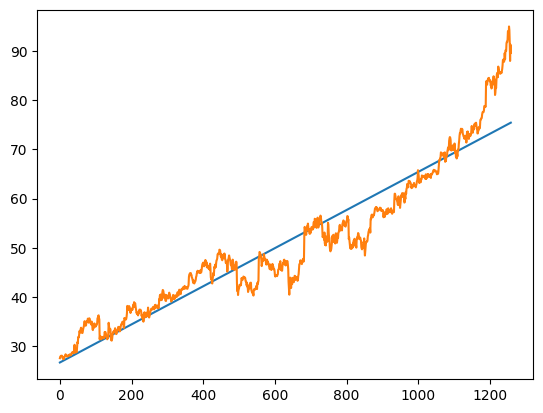

In [39]:
plt.plot(np.arange(len(price)),trendline)
plt.plot(np.arange(len(price)),price)
plt.show()

In [40]:
adf_test(price_detrended)

adf stats:-1.825
p-value stats:0.368
1%:-3.436
5%:-2.864
10%:-2.568


In [41]:
window=12
price_ma=price.rolling(window=window).mean()
price_detrended=price-price_ma
price_detrended=price_detrended.dropna()

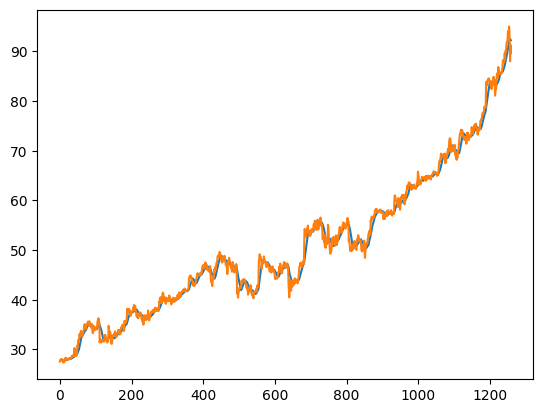

In [42]:
plt.plot(np.arange(len(price)),price_ma)
plt.plot(np.arange(len(price)),price)
plt.show() #movingaverage detrending

In [43]:
#seasonal adjustment

In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(price,model='additive',period=30)
price_adjusted=price/decomposition.seasonal
price_adjusted=price_adjusted.dropna()

In [45]:
adf_test(price_adjusted)

adf stats:-13.783
p-value stats:0.0
1%:-3.436
5%:-2.864
10%:-2.568


White noise and random walk

In [46]:
from statsmodels.stats.diagnostic import acorr_ljungbox

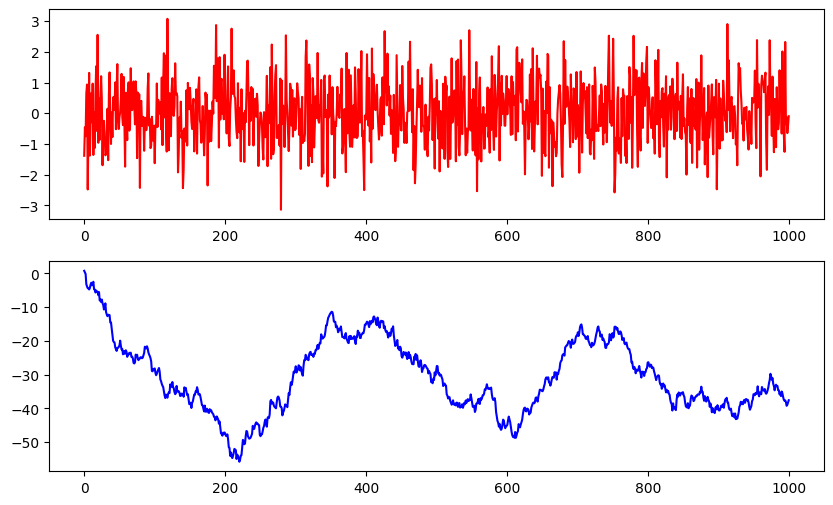

In [48]:
white_noise=np.random.normal(0,1,1000)
random_shocks=np.random.normal(0,1,1000)
random_walk=np.cumsum(random_shocks)
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(white_noise,color='red')
plt.subplot(2,1,2)
plt.plot(random_walk,color='blue')

In [49]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_test(series, lags=10):
    result = acorr_ljungbox(series, lags=lags, return_df=True)
    print(result)

In [50]:
ljung_box_test(white_noise)

     lb_stat  lb_pvalue
1   0.323418   0.569561
2   0.400743   0.818427
3   0.673926   0.879319
4   0.690628   0.952480
5   0.969297   0.965004
6   1.366823   0.967845
7   2.165097   0.950140
8   2.175041   0.975170
9   5.023338   0.832269
10  6.557586   0.766447


In [51]:
ljung_box_test(random_walk)

        lb_stat      lb_pvalue
1    985.428780  2.639655e-216
2   1954.078343   0.000000e+00
3   2905.562744   0.000000e+00
4   3840.905408   0.000000e+00
5   4760.274708   0.000000e+00
6   5663.903330   0.000000e+00
7   6551.414799   0.000000e+00
8   7422.799932   0.000000e+00
9   8277.649599   0.000000e+00
10  9115.374431   0.000000e+00


In [52]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_test(series, lags=10):
    result = acorr_ljungbox(series, lags=lags, return_df=True)

    print("Ljung-Box Test Results")
    print("----------------------")
    print(result)

    if (result['lb_pvalue'] < 0.05).any():
        print("\nConclusion: Pattern detected (autocorrelation present)")
    else:
        print("\nConclusion: No significant pattern (white noise)")

In [53]:
ljung_box_test(price)

Ljung-Box Test Results
----------------------
         lb_stat      lb_pvalue
1    1249.900986  8.721778e-274
2    2488.361705   0.000000e+00
3    3716.710273   0.000000e+00
4    4933.730586   0.000000e+00
5    6138.553623   0.000000e+00
6    7331.213003   0.000000e+00
7    8512.769502   0.000000e+00
8    9682.789106   0.000000e+00
9   10841.467940   0.000000e+00
10  11989.702598   0.000000e+00

Conclusion: Pattern detected (autocorrelation present)


In [54]:
price=data['close']